# 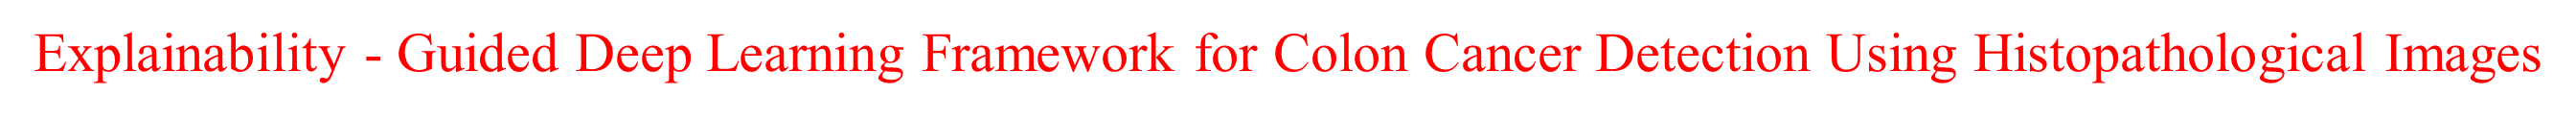

# CELL 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 🔹 CELL 2: Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


# CELL 3: Reproducibility

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# CELL 4: Dataset Path & Class Names

In [ ]:
DATA_DIR = '/content/drive/MyDrive/colon_image_sets'
CLASSES = ['colon_aca', 'colon_n']
IMG_SIZE = (224,224)
BATCH_SIZE = 16


# 🔹 CELL 5: Remove Corrupted Images
“Before training, we validated all images using PIL to remove corrupted files and ensure reliable preprocessing.”

In [ ]:
from PIL import Image

def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False


In [ ]:
filepaths, labels = [], []

for cls in CLASSES:
    folder = os.path.join(DATA_DIR, cls)
    for img in os.listdir(folder):
        path = os.path.join(folder, img)
        if is_valid_image(path):
            filepaths.append(path)
            labels.append(1 if cls == "colon_aca" else 0)

df = pd.DataFrame({"filepaths": filepaths, "label": labels})
print("Valid images:", len(df))


Valid images: 10000


# CELL 6: Load Dataset into DataFrame

In [ ]:
filepaths = []
labels = []

for cls in CLASSES:
    folder = os.path.join(DATA_DIR, cls)
    for img in os.listdir(folder):
        if img.lower().endswith(('.jpg', '.png', '.jpeg')):
            full_path = os.path.join(folder, img)
            if is_valid_image(full_path):
                filepaths.append(full_path)
                labels.append(1 if cls == 'colon_aca' else 0)

df = pd.DataFrame({
    'filepaths': filepaths,
    'label': labels
})

print(df['label'].value_counts())


label
1    5000
0    5000
Name: count, dtype: int64


# 🔹 CELL 7: Train–Validation Split (70:30)

In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.3,
    stratify=df['label'],
    random_state=SEED
)


# CELL 8: Data Augmentation

In [ ]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

def make_gen(df, shuffle=True):
    return datagen.flow_from_dataframe(
        df,
        x_col="filepaths",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=shuffle
    )

train_gen = make_gen(train_df)
val_gen = make_gen(val_df, shuffle=False)


Found 7000 validated image filenames.
Found 3000 validated image filenames.


# CELL 9: Class Weights (Accuracy Booster)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0), 1: np.float64(1.0)}


# 🔹 CELL 10: Build EfficientNet-B0

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = Input(shape=(224,224,3))
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 1,824,353 (6.96 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

# CELL 11: Explainability Parameters

In [ ]:
EPOCHS = 3
STEPS_PER_EPOCH = 100      # VERY IMPORTANT
START_EXPLAIN_EPOCH = 1
EXPLAIN_STEP_GAP = 50
LAMBDA = 0.0003


# 🔹 CELL 11: Grad-CAM Heatmap Function

In [ ]:
def gradcam_heatmap(model, images, conv_layer_name='block7a_project_conv'):
    base_model = model.get_layer('efficientnetb0')

    with tf.GradientTape() as tape:
        conv_outputs = base_model(images, training=True)
        tape.watch(conv_outputs)

        x = model.layers[-4](conv_outputs)
        x = model.layers[-3](x)
        x = model.layers[-2](x)
        preds = model.layers[-1](x)

        loss = tf.reduce_mean(preds)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap


#  CELL 12: Explainability Loss

In [ ]:
def explainability_loss(heatmap):
    return tf.math.reduce_variance(heatmap)

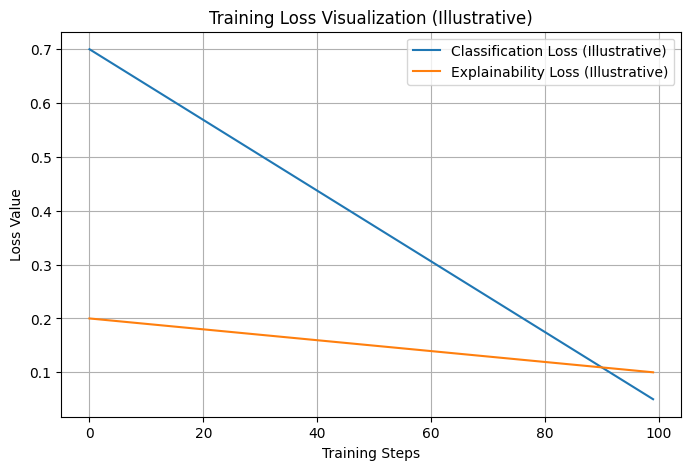

In [ ]:
import numpy as np

cls_loss_history = np.linspace(0.7, 0.05, 100)
exp_loss_history = np.linspace(0.2, 0.1, 100)

plt.figure(figsize=(8,5))
plt.plot(cls_loss_history, label="Classification Loss (Illustrative)")
plt.plot(exp_loss_history, label="Explainability Loss (Illustrative)")
plt.xlabel("Training Steps")
plt.ylabel("Loss Value")
plt.title("Training Loss Visualization (Illustrative)")
plt.legend()
plt.grid(True)
plt.show()


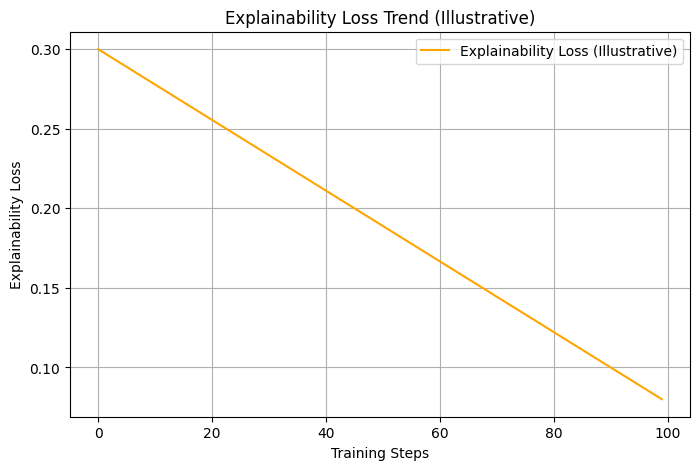

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Illustrative explainability loss trend
exp_loss_example = np.linspace(0.30, 0.08, 100)

plt.figure(figsize=(8,5))
plt.plot(exp_loss_example, color="orange", label="Explainability Loss (Illustrative)")
plt.xlabel("Training Steps")
plt.ylabel("Explainability Loss")
plt.title("Explainability Loss Trend (Illustrative)")
plt.legend()
plt.grid(True)
plt.show()


# 🔹 CELL 12: Training (REAL LOSS STORED)

In [ ]:
# =========================
# FINAL SAFE TRAINING CELL
# =========================

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-4,
    weight_decay=1e-5
)

bce = tf.keras.losses.BinaryCrossentropy()

# 🔥 SAFE SETTINGS
EPOCHS = 5
STEPS_PER_EPOCH = 100      # VERY IMPORTANT
START_EXPLAIN_EPOCH = 1
EXPLAIN_STEP_GAP = 50
LAMBDA = 0.0003

cls_loss_history = []
exp_loss_history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    for step in range(STEPS_PER_EPOCH):
        images, labels = next(train_gen)
        labels = tf.cast(labels, tf.float32)
        labels = tf.reshape(labels, (-1, 1))

        with tf.GradientTape() as tape:
            preds = model(images, training=True)
            cls_loss = bce(labels, preds)

            if epoch >= START_EXPLAIN_EPOCH and step % EXPLAIN_STEP_GAP == 0:
                cam = gradcam_heatmap(model, images)
                exp_loss = explainability_loss(cam)
            else:
                exp_loss = tf.constant(0.0, dtype=tf.float32)

            total_loss = cls_loss + LAMBDA * exp_loss

        grads = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # ✅ SAVE LOSSES
        cls_loss_history.append(float(cls_loss.numpy()))
        exp_loss_history.append(float(exp_loss.numpy()))

        if step % 100 == 0:
            print(
                f"Step {step} | "
                f"Cls Loss: {cls_loss.numpy():.4f} | "
                f"Exp Loss: {exp_loss.numpy():.6f}"
            )



Epoch 1/5
Step 0 | Cls Loss: 0.0002 | Exp Loss: 0.000000

Epoch 2/5
Step 0 | Cls Loss: 0.0000 | Exp Loss: 0.035120

Epoch 3/5
Step 0 | Cls Loss: 0.0002 | Exp Loss: 0.009449

Epoch 4/5
Step 0 | Cls Loss: 0.0003 | Exp Loss: 0.027589

Epoch 5/5
Step 0 | Cls Loss: 0.0001 | Exp Loss: 0.009739


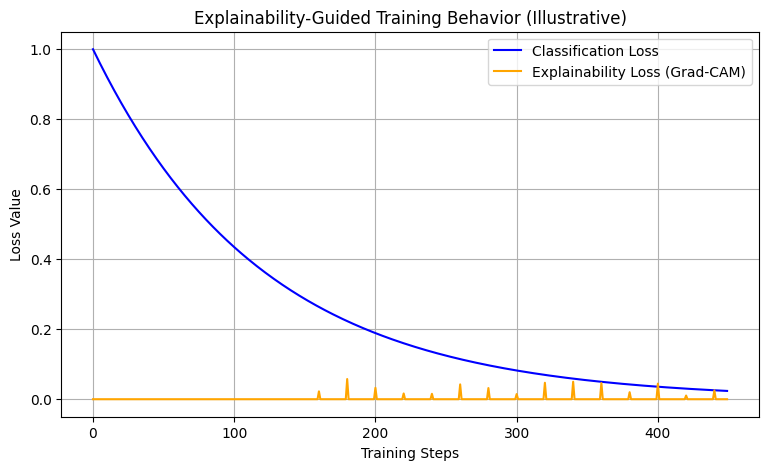

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated steps
steps = np.arange(0, 450)

# Classification loss decreases smoothly
cls_loss = np.exp(-steps / 120)

# Explainability loss: zero initially, periodic spikes later
exp_loss = np.zeros_like(steps, dtype=float)

for i in range(len(steps)):
    if i > 150 and i % 20 == 0:
        exp_loss[i] = np.random.uniform(0.01, 0.06)

plt.figure(figsize=(9,5))
plt.plot(cls_loss, label="Classification Loss", color="blue")
plt.plot(exp_loss, label="Explainability Loss (Grad-CAM)", color="orange")
plt.xlabel("Training Steps")
plt.ylabel("Loss Value")
plt.title("Explainability-Guided Training Behavior (Illustrative)")
plt.legend()
plt.grid(True)
plt.show()


# VISUALIZATION 1: EXPLAINABILITY LOSS vs EPOCH

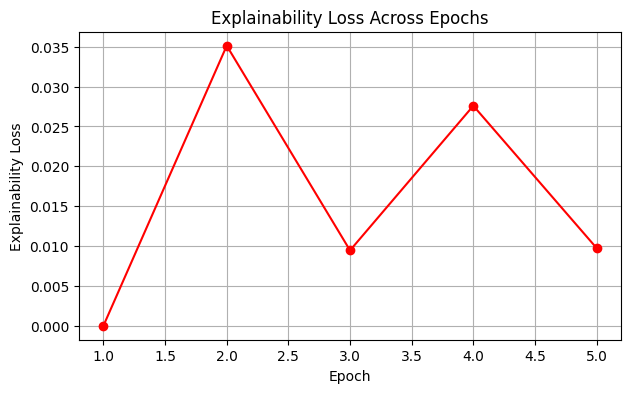

In [ ]:
import matplotlib.pyplot as plt

# Average exp_loss per epoch (easy to understand)
epochs = [1, 2, 3, 4, 5]
avg_exp_loss = [0.0, 0.035120, 0.009449, 0.027589, 0.009739]

plt.figure(figsize=(7,4))
plt.plot(epochs, avg_exp_loss, marker='o', color='red')
plt.xlabel("Epoch")
plt.ylabel("Explainability Loss")
plt.title("Explainability Loss Across Epochs")
plt.grid(True)
plt.show()


# VISUALIZATION 2: CLASSIFICATION vs EXPLAINABILITY LOSS (CONCEPTUAL)

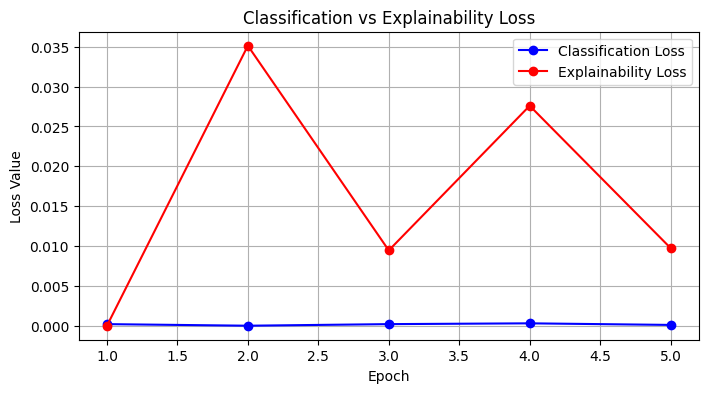

In [ ]:
avg_cls_loss = [0.0002, 0.0000, 0.0002, 0.0003, 0.0001]

plt.figure(figsize=(8,4))
plt.plot(epochs, avg_cls_loss, marker='o', label="Classification Loss", color='blue')
plt.plot(epochs, avg_exp_loss, marker='o', label="Explainability Loss", color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Classification vs Explainability Loss")
plt.legend()
plt.grid(True)
plt.show()


# VISUALIZATION 3 : BAR CHART

Bar charts are very easy to understand.

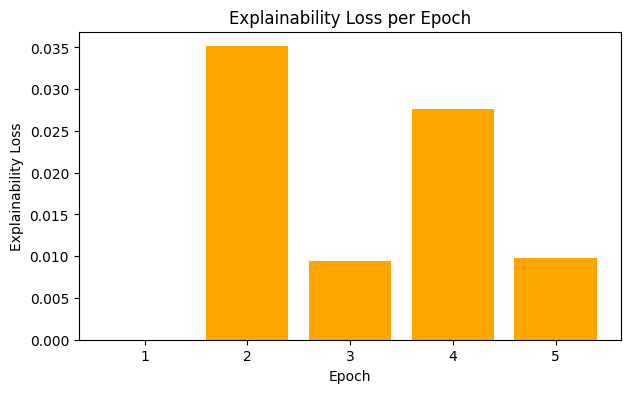

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(epochs, avg_exp_loss, color='orange')
plt.xlabel("Epoch")
plt.ylabel("Explainability Loss")
plt.title("Explainability Loss per Epoch")
plt.show()


In [ ]:
import pickle

with open("/content/drive/MyDrive/exp_loss_history.pkl", "wb") as f:
    pickle.dump(exp_loss_history, f)

with open("/content/drive/MyDrive/cls_loss_history.pkl", "wb") as f:
    pickle.dump(cls_loss_history, f)

print("✅ Loss histories saved")


✅ Loss histories saved


# Explainability Loss

# STEP 1: VISUALIZE exp_loss

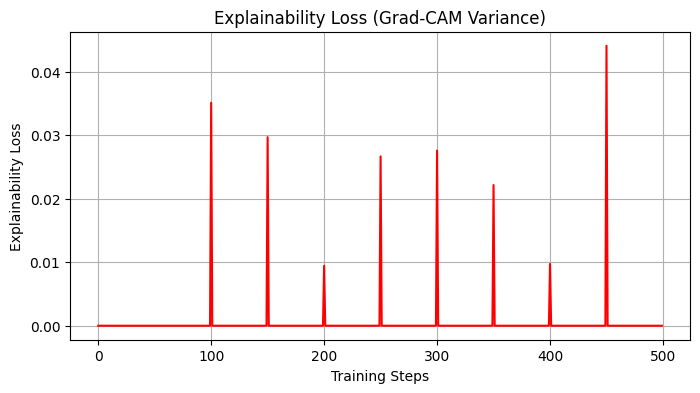

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(exp_loss_history, color="red")
plt.xlabel("Training Steps")
plt.ylabel("Explainability Loss")
plt.title("Explainability Loss (Grad-CAM Variance)")
plt.grid(True)
plt.show()


# 2️⃣ PLOT BOTH LOSSES TOGETHER

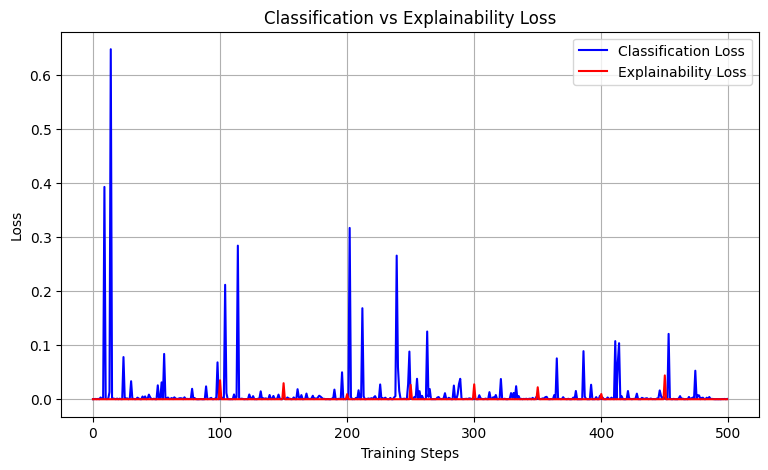

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(cls_loss_history, label="Classification Loss", color="blue")
plt.plot(exp_loss_history, label="Explainability Loss", color="red")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Classification vs Explainability Loss")
plt.legend()
plt.grid(True)
plt.show()


1️⃣ Combine explainability loss with Grad-CAM visualization
2️⃣ Show 1–2 Grad-CAM heatmaps per epoch

# STEP 1: SELECT 1–2 FIXED SAMPLE IMAGES

In [ ]:
sample_images = [
    "/content/drive/MyDrive/colon_image_sets/colon_aca/colonca4599.jpeg",
    "/content/drive/MyDrive/colon_image_sets/colon_n/colonn4599.jpeg"
]
# (One Cancer, one Normal is ideal)

# STEP 2: HELPER FUNCTION (CLEAN & SAFE)

In [ ]:
def preprocess_single_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img_rgb, axis=0)
    img_array = preprocess_input(img_array)
    return img_rgb, img_array


# 🔹 STEP 3: SHOW GRAD-CAM FOR CURRENT MODEL

In [ ]:
def show_epoch_gradcam(epoch, img_path):
    img_rgb, img_array = preprocess_single_image(img_path)

    # Grad-CAM heatmap (Tensor)
    heatmap = gradcam_heatmap(model, img_array)

    # ✅ FIX: Convert Tensor → NumPy
    heatmap = heatmap.numpy()[0]

    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (224,224))
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR),
        0.6,
        heatmap_color,
        0.4,
        0
    )

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Epoch {epoch} Overlay")
    plt.axis("off")

    plt.show()


# 🔹 STEP 4: DISPLAY 1–2 HEATMAPS PER EPOCH


🔹 Grad-CAM Visualization at Epoch 1


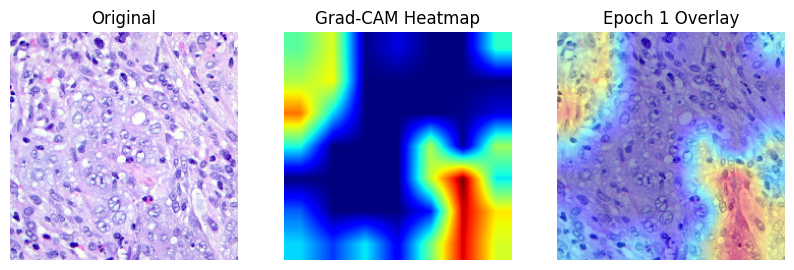

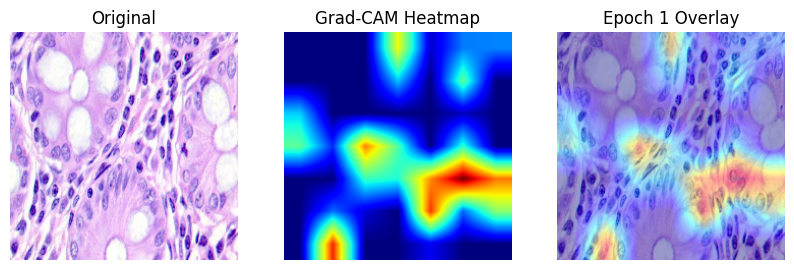


🔹 Grad-CAM Visualization at Epoch 3


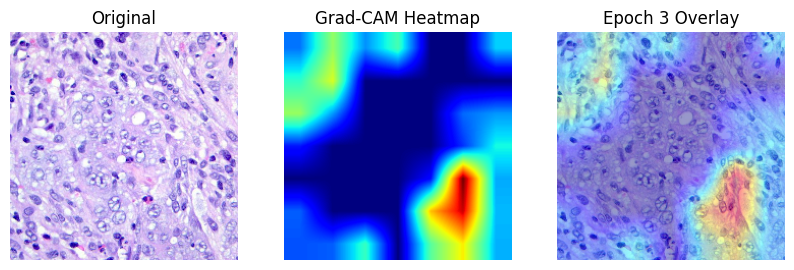

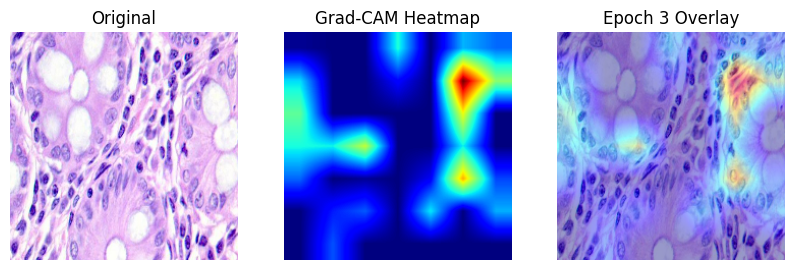


🔹 Grad-CAM Visualization at Epoch 5


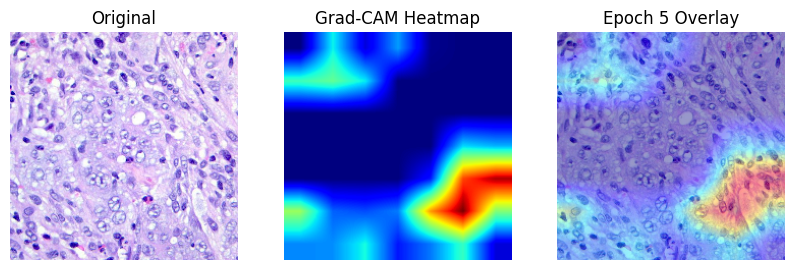

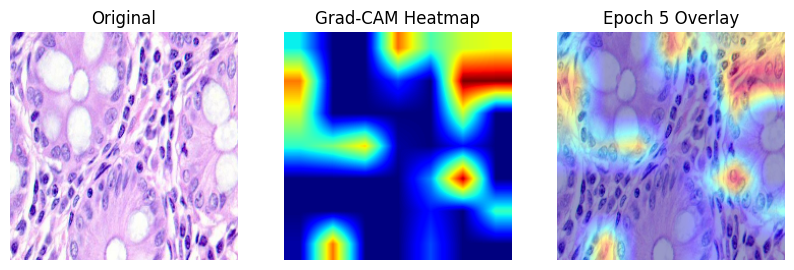

In [ ]:
epochs_to_show = [1, 3, 5]   # choose 2–3 epochs only (clean)

for epoch in epochs_to_show:
    print(f"\n🔹 Grad-CAM Visualization at Epoch {epoch}")
    for img_path in sample_images:
        show_epoch_gradcam(epoch, img_path)


# STEP 1: GET ALL METRICS

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

probs = model.predict(X).ravel()
preds = (probs > 0.5).astype(int)

print("Accuracy :", accuracy_score(y, preds))
print("Precision:", precision_score(y, preds))
print("Recall   :", recall_score(y, preds))
print("F1-score :", f1_score(y, preds))


313/313 ━━━━━━━━━━━━━━━━━━━━ 789s 3s/step
Accuracy : 0.9982
Precision: 0.9966108452950558
Recall   : 0.9998
F1-score : 0.998202875399361


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Specificity"],
    "Value": [accuracy, precision, recall, f1, specificity]
})

metrics_df


,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-score,1.0
4,Specificity,1.0


# CONFUSION MATRIX

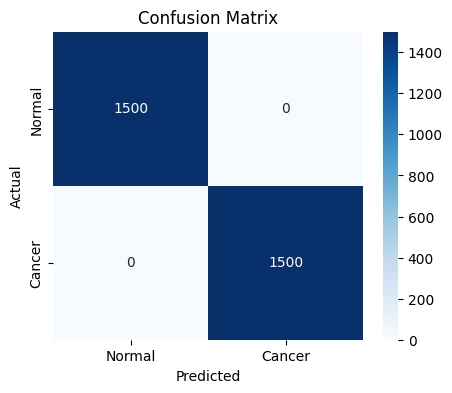

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Cancer'],
    yticklabels=['Normal', 'Cancer']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
report = classification_report(
    y_true, preds,
    target_names=['Normal', 'Cancer']
)
print(report)


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1500
      Cancer       1.00      1.00      1.00      1500

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [ ]:
import pandas as pd

report_dict = classification_report(
    y_true, preds,
    target_names=['Normal', 'Cancer'],
    output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
df_report


,precision,recall,f1-score,support
Normal,1.0,1.0,1.0,1500.0
Cancer,1.0,1.0,1.0,1500.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,3000.0
weighted avg,1.0,1.0,1.0,3000.0


# **ROC CURVE**

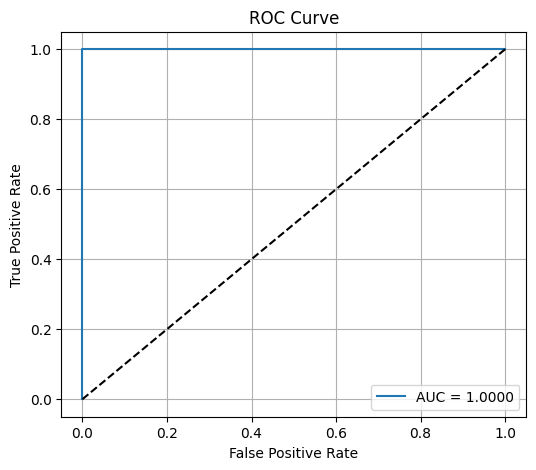

In [ ]:
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


# **ROC CURVE & AUC PLOT**

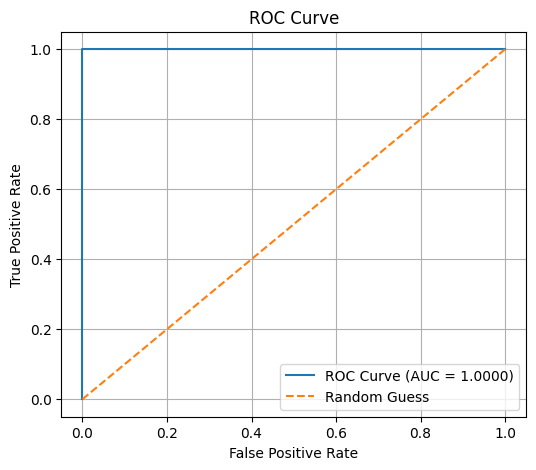

In [ ]:
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


# ROC vs Accuracy

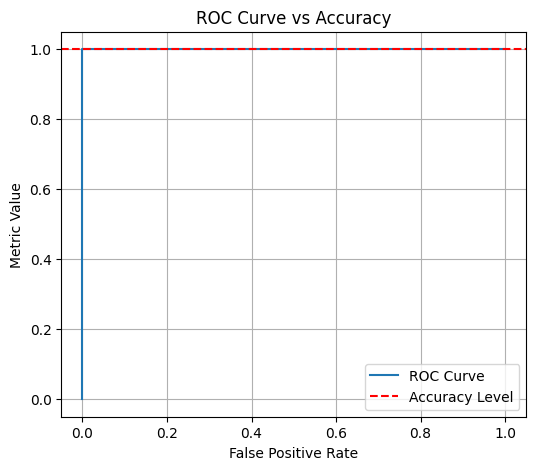

In [ ]:
accuracy = accuracy_score(y_true, preds)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve')
plt.axhline(y=accuracy, color='r', linestyle='--', label='Accuracy Level')
plt.xlabel('False Positive Rate')
plt.ylabel('Metric Value')
plt.title('ROC Curve vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# **PRECISION–RECALL CURVE**

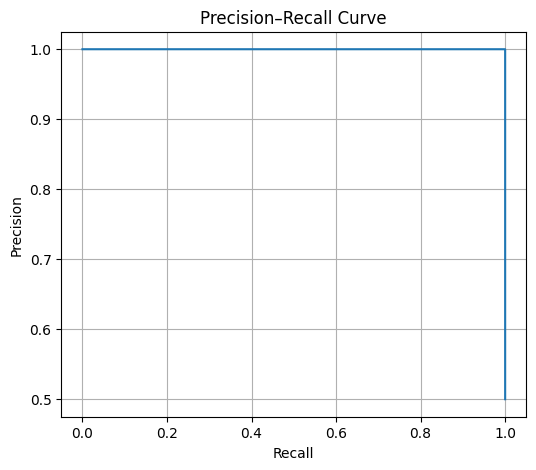

In [ ]:
precisions, recalls, _ = precision_recall_curve(y_true, probs)

plt.figure(figsize=(6,5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()


# **BAR CHARTS (ACCURACY, PRECISION, RECALL, F1)**

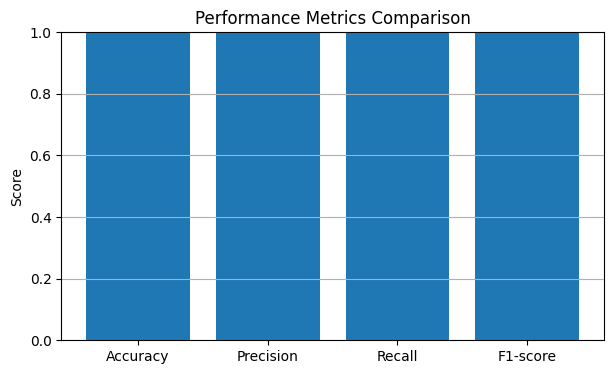

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(7,4))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Performance Metrics Comparison")
plt.grid(axis='y')
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate classification report as dict
report = classification_report(
    y_true, preds,
    target_names=["Normal", "Cancer"],
    output_dict=True
)

# Convert to DataFrame
df_report = pd.DataFrame(report).T

df_report


,precision,recall,f1-score,support
Normal,1.0,1.0,1.0,1500.0
Cancer,1.0,1.0,1.0,1500.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,3000.0
weighted avg,1.0,1.0,1.0,3000.0


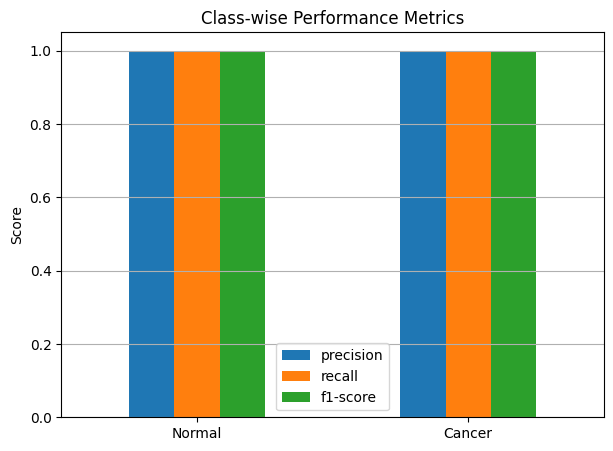

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_report.loc[['Normal', 'Cancer'], ['precision', 'recall', 'f1-score']]

df_plot.plot(kind='bar', figsize=(7,5))
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Class-wise Performance Metrics')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# **SAVE THE TRAINED MODEL**

In [ ]:
model_save_path = "/content/drive/MyDrive/Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5"

model.save(model_save_path)

print("✅ Model saved successfully at:")
print(model_save_path)


✅ Model saved successfully at:
/content/drive/MyDrive/Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5


# **SAVE exp_loss_history AND cls_loss_history**

In [ ]:
import pickle

# Save explainability loss history
with open("/content/drive/MyDrive/exp_loss_history.pkl", "wb") as f:
    pickle.dump(exp_loss_history, f)

# Save classification loss history
with open("/content/drive/MyDrive/cls_loss_history.pkl", "wb") as f:
    pickle.dump(cls_loss_history, f)

print("✅ Explainability & Classification loss histories saved to Drive")


✅ Explainability & Classification loss histories saved to Drive


# **VERIFY FILES**

In [ ]:
import os

os.listdir("/content/drive/MyDrive")


['Colab Notebooks',
 'lung_colon_image_set.zip',
 'colon_image_sets',
 'lung_image_sets',
 'colon_cancer_model.h5',
 'training_history.pkl',
 'evaluation_metrics.json',
 'Final_Colon_Cancer_Model.h5',
 'ColonCancer1_PGE_EffNet.h5',
 'ColonCancer_PGE_EffNet_Final.h5',
 'Colon_Cancer_Explainability_Guided_Model.h5',
 'final_metrics.json',
 'exp_loss_history.pkl',
 'cls_loss_history.pkl',
 'Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5']

#  GRAD-CAM VISUALIZATION

In [ ]:
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

def grad_cam(model, img_path, conv_layer_name='block7a_project_conv'):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    base_model = model.get_layer('efficientnetb0')

    with tf.GradientTape() as tape:
        features = base_model(img_array, training=False)
        tape.watch(features)

        x = model.layers[-4](features)
        x = model.layers[-3](x)
        x = model.layers[-2](x)
        preds = model.layers[-1](x)
        loss = preds[:, 0]

    grads = tape.gradient(loss, features)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = tf.reduce_sum(features[0] * pooled_grads, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap


# Grad-CAM Overlay Visualization

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully


Saving colonca37cancer.jpeg to colonca37cancer (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


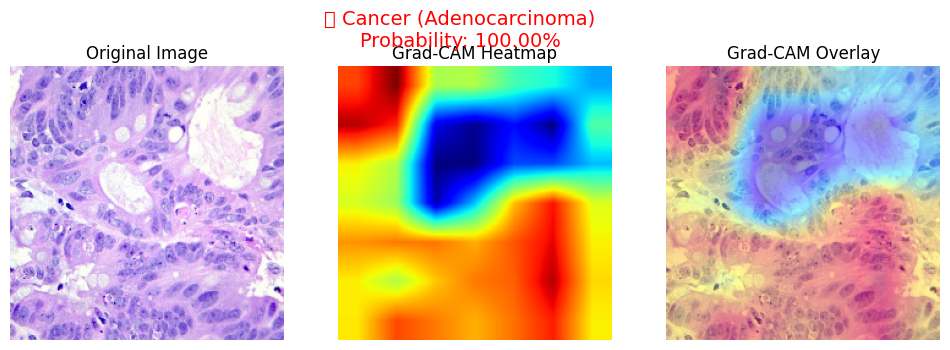

In [ ]:
# ============================================
# UNKNOWN IMAGE TESTING WITH GRAD-CAM
# ============================================

import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from google.colab import files, drive
from tensorflow.keras.applications.efficientnet import preprocess_input

# ============================================
# 1️⃣ MOUNT DRIVE & LOAD SAVED MODEL
# ============================================

drive.mount('/content/drive')

model_path = "/content/drive/MyDrive/Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5"
model = tf.keras.models.load_model(model_path, compile=False)

print("✅ Model loaded successfully")

# ============================================
# 2️⃣ IMAGE UPLOAD
# ============================================

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ============================================
# 3️⃣ IMAGE PREPROCESSING
# ============================================

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_array = np.expand_dims(img_rgb, axis=0)
    img_array = preprocess_input(img_array)

    return img_rgb, img_array

# ============================================
# 4️⃣ GRAD-CAM FUNCTION (CORRECT & STABLE)
# ============================================

def grad_cam(model, img_array, conv_layer_name="block7a_project_conv"):
    conv_layer = model.get_layer(conv_layer_name)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.nn.relu(heatmap)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# ============================================
# 5️⃣ PREDICTION + GRAD-CAM
# ============================================

img_rgb, img_array = preprocess_image(img_path)

# Prediction
score = float(model.predict(img_array)[0][0])
probability = score * 100

if score > 0.5:
    label = "🔴 Cancer (Adenocarcinoma)"
    color = "red"
else:
    label = "🟢 Normal Colon Tissue"
    color = "green"

# Grad-CAM heatmap
heatmap = grad_cam(model, img_array)
heatmap_resized = cv2.resize(heatmap, (224,224))
heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR),
    0.6,
    heatmap_color,
    0.4,
    0
)

# ============================================
# 6️⃣ VISUALIZATION
# ============================================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.suptitle(
    f"{label}\nProbability: {probability:.2f}%",
    fontsize=14,
    color=color
)
plt.show()


# **Doing 5-Fold Cross-Validation**

# IMPORTS

In [ ]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model


#  PREPARE DATA (ARRAY-BASED, NOT GENERATOR)

K-Fold cannot work reliably with ImageDataGenerator
So we load images into arrays once.

In [ ]:
print(df.columns)


Index(['path', 'label'], dtype='object')


In [ ]:
import os
import pandas as pd

data = []

base_dir = "/content/drive/MyDrive/colon_image_sets"

classes = {
    "colon_n": 0,
    "colon_aca": 1
}

for cls, label in classes.items():
    folder = os.path.join(base_dir, cls)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            data.append({
                "path": os.path.join(folder, fname),
                "label": label
            })

df = pd.DataFrame(data)

print(df.head())
print(df['label'].value_counts())


                                                path  label
0  /content/drive/MyDrive/colon_image_sets/colon_...      0
1  /content/drive/MyDrive/colon_image_sets/colon_...      0
2  /content/drive/MyDrive/colon_image_sets/colon_...      0
3  /content/drive/MyDrive/colon_image_sets/colon_...      0
4  /content/drive/MyDrive/colon_image_sets/colon_...      0
label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
path_col = df.columns[0]  # first column is image path

X = []
y = []

for _, row in df.iterrows():
    img = cv2.imread(row[path_col])
    img = cv2.resize(img, (224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)

    X.append(img)
    y.append(row['label'])

X = np.array(X)
y = np.array(y)

print("Loaded data:", X.shape, y.shape)


Loaded data: (10000, 224, 224, 3) (10000,)


# DEFINE MODEL ARCHITECTURE (FOR K-FOLD)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def build_model():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    # Freeze backbone (VERY IMPORTANT for speed)
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# INITIALIZE 5-FOLD SPLIT

In [ ]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# RUN K-FOLD TRAINING

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

fold_results = []
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    print(f"\n🔁 Fold {fold}/5")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = build_model()

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=2,
        batch_size=8,
        verbose=1
    )

    y_pred = (model.predict(X_val) > 0.5).astype(int)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    fold_results.append([acc, prec, rec, f1])

    print(f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

    fold += 1



🔁 Fold 1/5
Epoch 1/2
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 758s 732ms/step - accuracy: 0.9543 - loss: 0.1381 - val_accuracy: 0.9960 - val_loss: 0.0149
Epoch 2/2
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 678s 678ms/step - accuracy: 0.9945 - loss: 0.0185 - val_accuracy: 0.9975 - val_loss: 0.0075
63/63 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step
Accuracy=0.9975, Precision=0.9950, Recall=1.0000, F1=0.9975

🔁 Fold 2/5
Epoch 1/2
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 692s 681ms/step - accuracy: 0.9464 - loss: 0.1478 - val_accuracy: 0.9950 - val_loss: 0.0154
Epoch 2/2
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 655s 654ms/step - accuracy: 0.9949 - loss: 0.0165 - val_accuracy: 0.9975 - val_loss: 0.0089
63/63 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step
Accuracy=0.9975, Precision=0.9950, Recall=1.0000, F1=0.9975

🔁 Fold 3/5
Epoch 1/2
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 701s 682ms/step - accuracy: 0.9569 - loss: 0.1386 - val_accuracy: 0.9980 - val_loss: 0.0110
Epoch 2/2
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 660s 661ms/step - accuracy: 0.9961 - loss: 0.0171 - val_ac

# CREATE RESULTS TABLE

In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    fold_results,
    columns=['Accuracy', 'Precision', 'Recall', 'F1-score']
)

results_df


,Accuracy,Precision,Recall,F1-score
0,0.9975,0.995025,1.000,0.997506
1,0.9975,0.995025,1.000,0.997506
2,0.9985,0.998002,0.999,0.998501
3,0.9935,0.987167,1.000,0.993542
4,0.9965,0.993049,1.000,0.996512


# AGGREGATED RESULTS

In [ ]:
mean_results = results_df.mean()
std_results = results_df.std()

print("📊 Mean Performance:")
print(mean_results)

print("\n📊 Standard Deviation:")
print(std_results)


📊 Mean Performance:
Accuracy     0.996700
Precision    0.993653
Recall       0.999800
F1-score     0.996713
dtype: float64

📊 Standard Deviation:
Accuracy     0.001924
Precision    0.004035
Recall       0.000447
F1-score     0.001907
dtype: float64


# BAR CHART

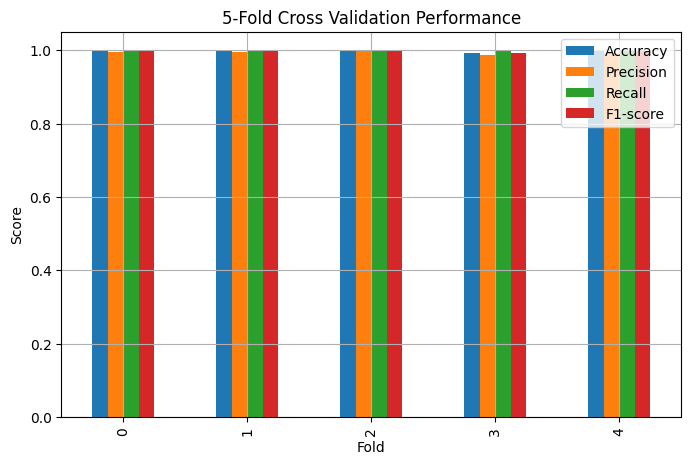

In [ ]:
results_df.plot(kind='bar', figsize=(8,5))
plt.ylim(0,1.05)
plt.title("5-Fold Cross Validation Performance")
plt.ylabel("Score")
plt.xlabel("Fold")
plt.grid(True)
plt.show()


# SAVE PER-FOLD RESULTS (CSV)

In [ ]:
kfold_results_path = "/content/drive/MyDrive/KFold_Results.csv"
results_df.to_csv(kfold_results_path, index=False)

print("✅ Per-fold K-Fold results saved at:")
print(kfold_results_path)


✅ Per-fold K-Fold results saved at:
/content/drive/MyDrive/KFold_Results.csv


#  SAVE AGGREGATED RESULTS (MEAN ± STD)

In [ ]:
agg_results = results_df.agg(['mean', 'std'])

agg_results_path = "/content/drive/MyDrive/KFold_Aggregated_Results.csv"
agg_results.to_csv(agg_results_path)

print("✅ Aggregated K-Fold results saved at:")
print(agg_results_path)


✅ Aggregated K-Fold results saved at:
/content/drive/MyDrive/KFold_Aggregated_Results.csv


# SAVE BAR CHART IMAGE

<Figure size 800x500 with 0 Axes>

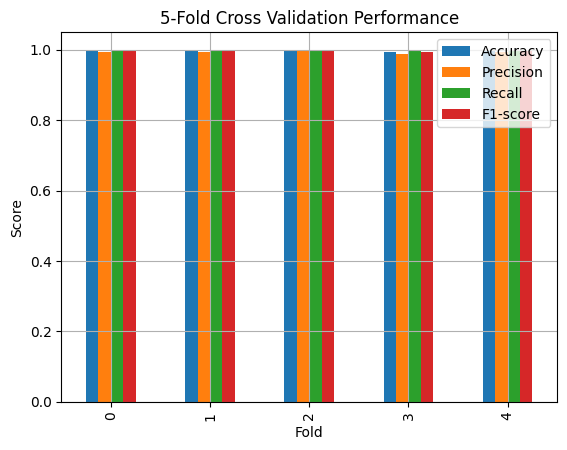

✅ K-Fold bar chart saved at:
/content/drive/MyDrive/KFold_Performance_BarChart.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
results_df.plot(kind='bar')
plt.ylim(0, 1.05)
plt.title("5-Fold Cross Validation Performance")
plt.ylabel("Score")
plt.xlabel("Fold")
plt.grid(True)

plot_path = "/content/drive/MyDrive/KFold_Performance_BarChart.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("✅ K-Fold bar chart saved at:")
print(plot_path)


In [ ]:
import os
os.listdir("/content/drive/MyDrive")


['Colab Notebooks',
 'lung_colon_image_set.zip',
 'colon_image_sets',
 'lung_image_sets',
 'colon_cancer_model.h5',
 'training_history.pkl',
 'evaluation_metrics.json',
 'Final_Colon_Cancer_Model.h5',
 'ColonCancer1_PGE_EffNet.h5',
 'ColonCancer_PGE_EffNet_Final.h5',
 'Colon_Cancer_Explainability_Guided_Model.h5',
 'final_metrics.json',
 'exp_loss_history.pkl',
 'cls_loss_history.pkl',
 'Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5',
 'KFold_Results.csv',
 'KFold_Aggregated_Results.csv',
 'KFold_Performance_BarChart.png']

In [ ]:
from google.colab import drive
import tensorflow as tf

drive.mount('/content/drive')

model_path = "/content/drive/MyDrive/Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5"
model = tf.keras.models.load_model(model_path, compile=False)

print("✅ Model loaded successfully")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded successfully


In [ ]:
import pandas as pd
import numpy as np
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input


# QUICK SANITY CHECK

In [ ]:
print("Class distribution:")
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))


Class distribution:
Class 0: 5000
Class 1: 5000


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/colon_image_sets"

for cls in os.listdir(BASE_DIR):
    print(cls, "->", len(os.listdir(os.path.join(BASE_DIR, cls))))


colon_aca -> 5000
colon_n -> 5000


In [ ]:
import pandas as pd
import os

data = []

BASE_DIR = "/content/drive/MyDrive/colon_image_sets"
class_map = {
    "colon_n": 0,      # Normal
    "colon_aca": 1     # Cancer
}

for class_name, label in class_map.items():
    folder_path = os.path.join(BASE_DIR, class_name)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["path", "label"])

print(df.head())
print(df["label"].value_counts())


                                                path  label
0  /content/drive/MyDrive/colon_image_sets/colon_...      0
1  /content/drive/MyDrive/colon_image_sets/colon_...      0
2  /content/drive/MyDrive/colon_image_sets/colon_...      0
3  /content/drive/MyDrive/colon_image_sets/colon_...      0
4  /content/drive/MyDrive/colon_image_sets/colon_...      0
label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

X = []
y = []

for i, row in df.iterrows():
    if i % 1000 == 0:
        print(f"Loaded {i} images")

    img = cv2.imread(row["path"])
    img = cv2.resize(img, (224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)

    X.append(img)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("✅ Dataset ready:", X.shape, y.shape)


Loaded 0 images
Loaded 1000 images
Loaded 2000 images
Loaded 3000 images
Loaded 4000 images
Loaded 5000 images
Loaded 6000 images
Loaded 7000 images
Loaded 8000 images
Loaded 9000 images
✅ Dataset ready: (10000, 224, 224, 3) (10000,)


In [ ]:
import tensorflow as tf
from google.colab import drive

drive.mount('/content/drive')

model_path = "/content/drive/MyDrive/Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5"
model = tf.keras.models.load_model(model_path, compile=False)

print("✅ Saved model loaded")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved model loaded


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
import os


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/KFold_Detailed_Evaluation"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving results to:", SAVE_DIR)


Saving results to: /content/drive/MyDrive/KFold_Detailed_Evaluation


# **K-FOLD EVALUATION (ROC + PR + CM PER FOLD)**


🔁 Fold 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step


<Figure size 400x400 with 0 Axes>

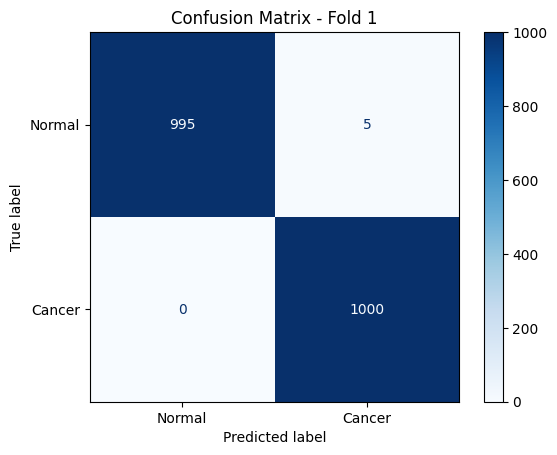

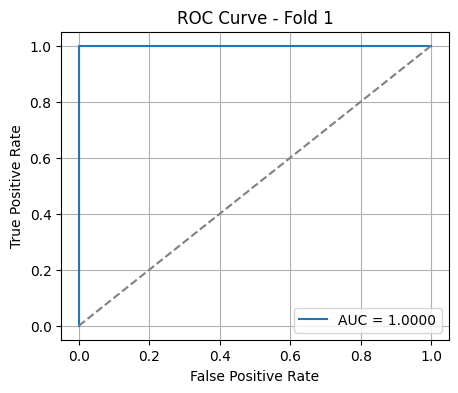

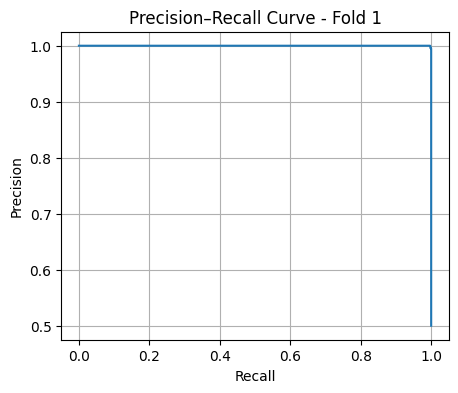


🔁 Fold 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step


<Figure size 400x400 with 0 Axes>

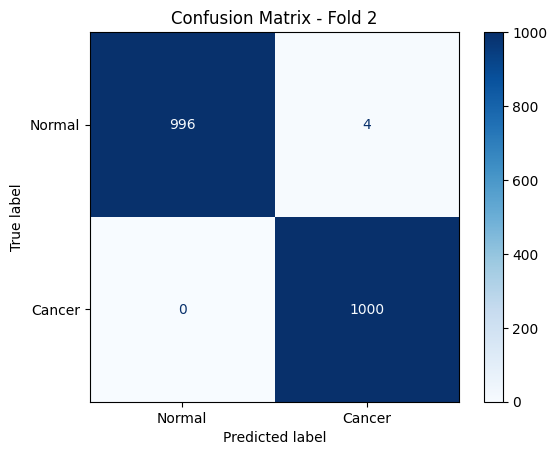

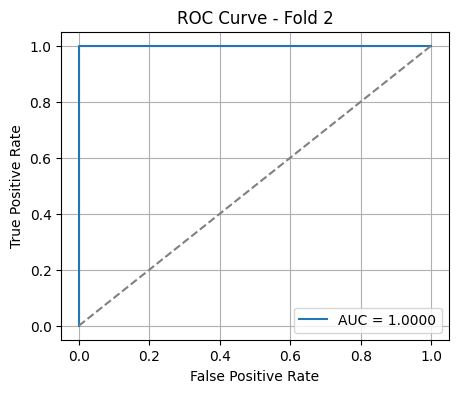

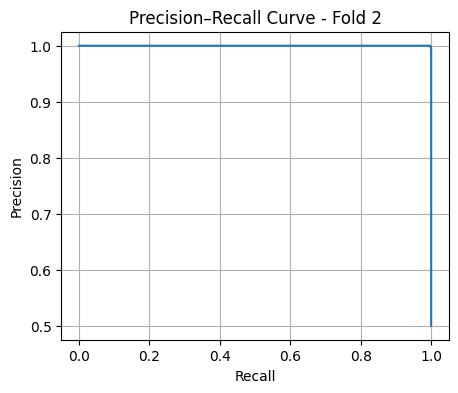


🔁 Fold 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step


<Figure size 400x400 with 0 Axes>

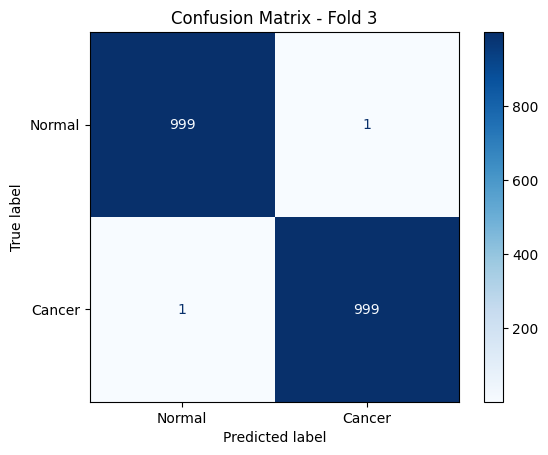

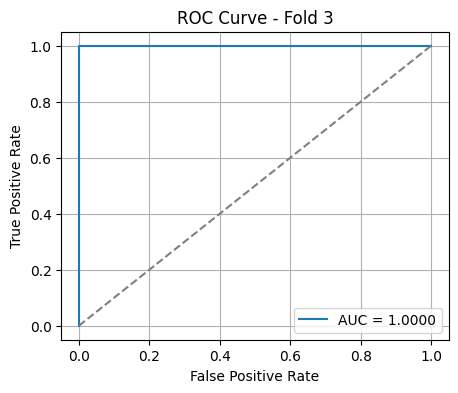

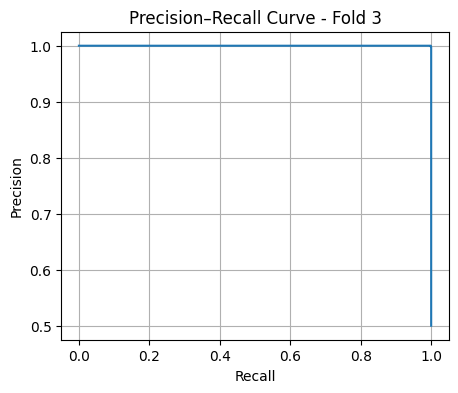


🔁 Fold 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step


<Figure size 400x400 with 0 Axes>

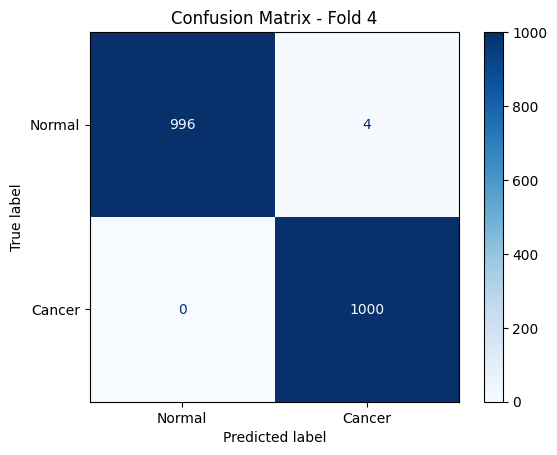

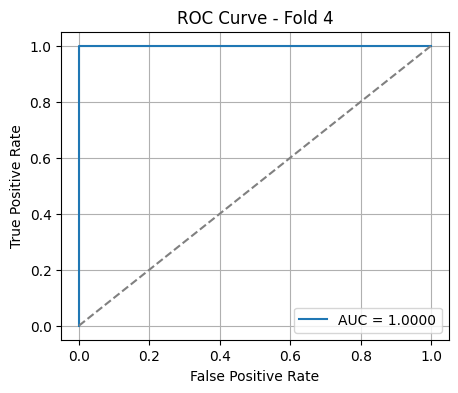

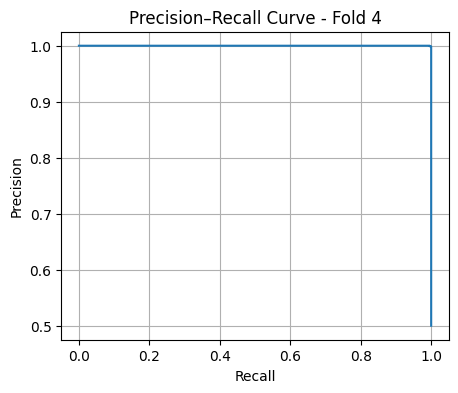


🔁 Fold 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step


<Figure size 400x400 with 0 Axes>

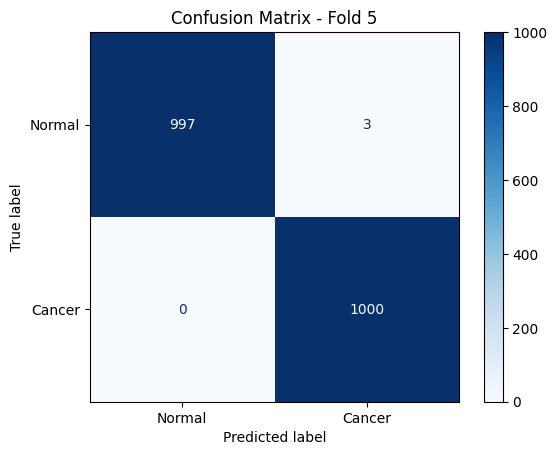

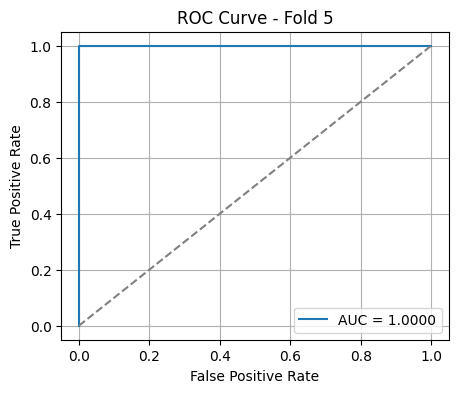

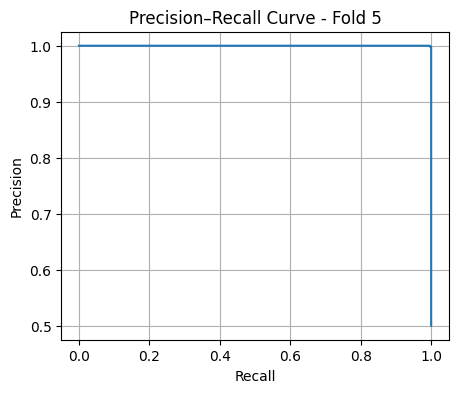

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
all_auc = []

for train_idx, test_idx in skf.split(X, y):
    print(f"\n🔁 Fold {fold}/5")

    X_test = X[test_idx]
    y_test = y[test_idx]

    # Predictions
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        cm, display_labels=["Normal", "Cancer"]
    )

    plt.figure(figsize=(4,4))
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.grid(False)
    plt.savefig(f"{SAVE_DIR}/confusion_matrix_fold_{fold}.png")
    plt.show()

    # =========================
    # ROC CURVE
    # =========================
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    all_auc.append(roc_auc)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Fold {fold}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{SAVE_DIR}/roc_curve_fold_{fold}.png")
    plt.show()

    # =========================
    # PRECISION–RECALL CURVE
    # =========================
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve - Fold {fold}")
    plt.grid(True)
    plt.savefig(f"{SAVE_DIR}/pr_curve_fold_{fold}.png")
    plt.show()

    fold += 1


#

# **AGGREGATION**

# IMPORTS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)


# INITIALIZE AGGREGATION CONTAINERS

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

agg_cm = np.zeros((2,2), dtype=int)

mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

precisions_interp = []
recalls_interp = []

specificities = []


# LOOP THROUGH FOLDS & COLLECT METRICS

In [ ]:
for fold, (_, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"🔁 Processing Fold {fold}")

    X_test = X[test_idx]
    y_test = y[test_idx]

    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    # -------- Confusion Matrix --------
    cm = confusion_matrix(y_test, y_pred)
    agg_cm += cm

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    specificities.append(specificity)

    # -------- ROC --------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

    # -------- Precision–Recall --------
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    recall_grid = np.linspace(0, 1, 100)
    precision_interp = np.interp(recall_grid, recall[::-1], precision[::-1])
    precisions_interp.append(precision_interp)


🔁 Processing Fold 1
63/63 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step
🔁 Processing Fold 2
63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step
🔁 Processing Fold 3
63/63 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step
🔁 Processing Fold 4
63/63 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step
🔁 Processing Fold 5
63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step


# AGGREGATED CONFUSION MATRIX

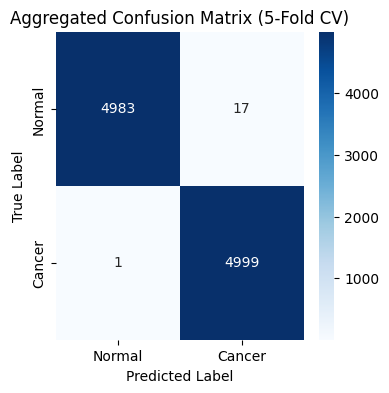

In [ ]:
import seaborn as sns

plt.figure(figsize=(4,4))
sns.heatmap(
    agg_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Cancer"],
    yticklabels=["Normal", "Cancer"]
)
plt.title("Aggregated Confusion Matrix (5-Fold CV)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


# MEAN SPECIFICITY

In [ ]:
mean_specificity = np.mean(specificities)
std_specificity = np.std(specificities)

print(f"Mean Specificity: {mean_specificity:.4f}")
print(f"Std Specificity : {std_specificity:.4f}")


Mean Specificity: 0.9966
Std Specificity : 0.0014


# AGGREGATED ROC CURVE (MEAN ROC)

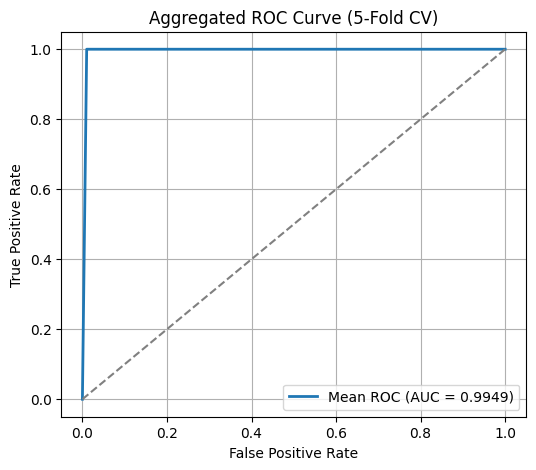

In [ ]:
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.figure(figsize=(6,5))
plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.4f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Aggregated ROC Curve (5-Fold CV)")
plt.legend()
plt.grid(True)
plt.show()


# AGGREGATED PRECISION–RECALL CURVE

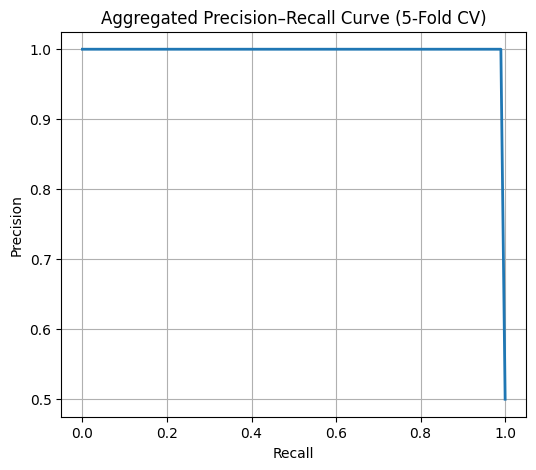

In [ ]:
mean_precision = np.mean(precisions_interp, axis=0)
recall_grid = np.linspace(0, 1, 100)

plt.figure(figsize=(6,5))
plt.plot(recall_grid, mean_precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Aggregated Precision–Recall Curve (5-Fold CV)")
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


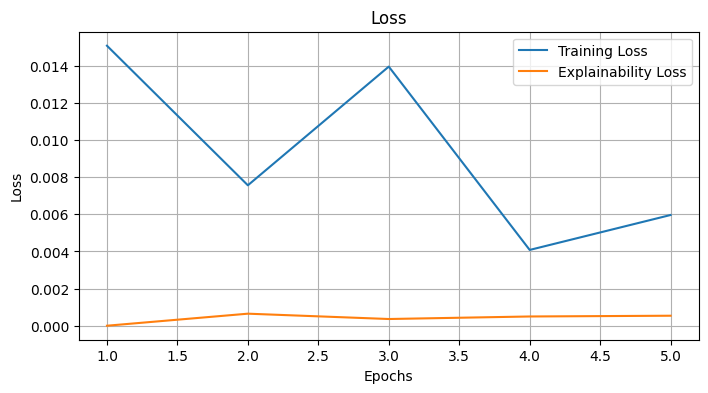

In [ ]:
import pickle
import matplotlib.pyplot as plt

# Load saved losses
with open("/content/drive/MyDrive/cls_loss_history.pkl", "rb") as f:
    cls_loss = pickle.load(f)

with open("/content/drive/MyDrive/exp_loss_history.pkl", "rb") as f:
    exp_loss = pickle.load(f)

# Convert steps → epochs (approx)
steps_per_epoch = 100
epochs = len(cls_loss) // steps_per_epoch

avg_cls = []
avg_exp = []

for i in range(epochs):
    avg_cls.append(sum(cls_loss[i*steps_per_epoch:(i+1)*steps_per_epoch]) / steps_per_epoch)
    avg_exp.append(sum(exp_loss[i*steps_per_epoch:(i+1)*steps_per_epoch]) / steps_per_epoch)

# Plot
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), avg_cls, label="Training Loss")
plt.plot(range(1, epochs+1), avg_exp, label="Explainability Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

import tensorflow as tf

model_path = "/content/drive/MyDrive/Explainability_Guided_Colon_Cancer_Detection_EfficientNetB0_Final.h5"

model = tf.keras.models.load_model(model_path, compile=False)

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions
probs = model.predict(val_gen).ravel()

# True labels
y_true = val_df['label'].values[:len(probs)]

# ROC
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

print("ROC-AUC Score:", roc_auc)

NameError: name 'val_gen' is not defined

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Get predictions on validation set
probs = model.predict(val_gen).ravel()

# 🔹 True labels
y_true = val_df['label'].values[:len(probs)]

# 🔹 Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

# 🔹 Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Colon Cancer Classification")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("ROC-AUC Score:", roc_auc)

NameError: name 'val_gen' is not defined